In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("data.csv")
df

,Unnamed: 0,date,time,power,workday
0,0,2022-01-01,0.00,0.000000e+00,0
1,1,2022-01-01,0.25,0.000000e+00,0
2,2,2022-01-01,0.50,0.000000e+00,0
3,3,2022-01-01,0.75,0.000000e+00,0
4,4,2022-01-01,1.00,0.000000e+00,0
...,...,...,...,...,...
77947,77947,2024-03-22,22.75,-1.367699e-07,1
77948,77948,2024-03-22,23.00,-1.367699e-07,1
77949,77949,2024-03-22,23.25,-1.367699e-07,1
77950,77950,2024-03-22,23.50,-1.367699e-07,1


In [20]:
dates = np.unique(df['date'])
lst = []
for date in dates:
    lst.append(list(df[df['date'] == date]['power']))

In [23]:
X = np.array(lst)

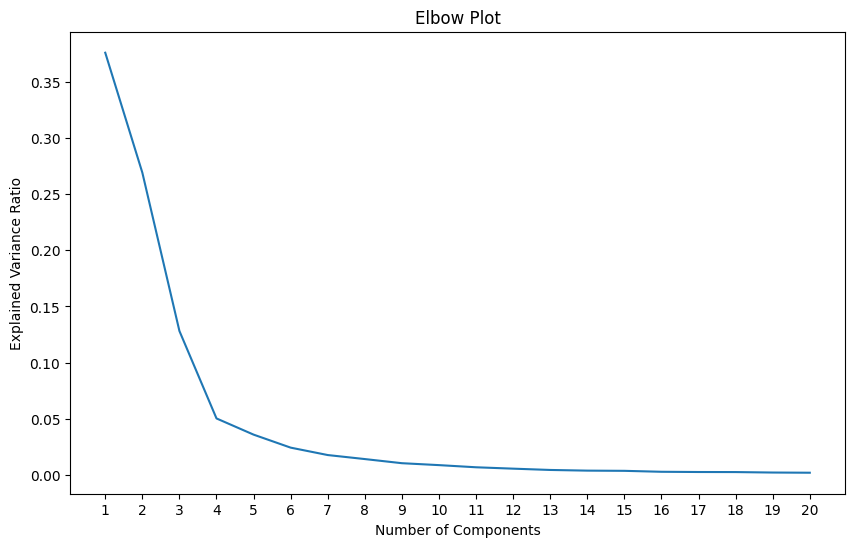

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler


# Standardize the data using StandardScaler
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# Initialize PCA
pca = PCA()

# Fit PCA
pca.fit(X_standardized)

# Plot explained variance ratio
MAX_PC_IN_GRAPH = 20

plt.figure(figsize=(10, 6))
plt.plot(range(1, MAX_PC_IN_GRAPH + 1), pca.explained_variance_ratio_[:MAX_PC_IN_GRAPH])
plt.title('Elbow Plot')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.xticks(np.arange(1, MAX_PC_IN_GRAPH + 1))
plt.show()


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


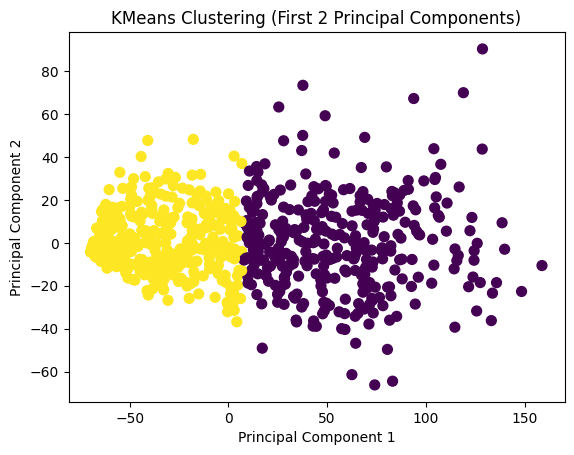

In [145]:
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

K = 2

# PCA for dimensionality reduction
pca = PCA(n_components=8)
X_pca = pca.fit_transform(X)

# Initialize KMeans with k=2
kmeans = KMeans(n_clusters=K)

# Fit the model and predict clusters
clusters = kmeans.fit_predict(X_pca)

# Plot the clustered data using the first two principal components
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', marker='o', s=50)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clustering (First 2 Principal Components)")
plt.show()

In [146]:
# Inverse transform cluster centers to original feature space
cluster_centers_pca = kmeans.cluster_centers_
cluster_centers = pca.inverse_transform(cluster_centers_pca)

# Calculate median vector for each cluster
median_vectors = []
for cluster_label in range(K):
    cluster_points = X[clusters == cluster_label]
    median_vector = np.median(cluster_points, axis=0)
    median_vectors.append(median_vector)

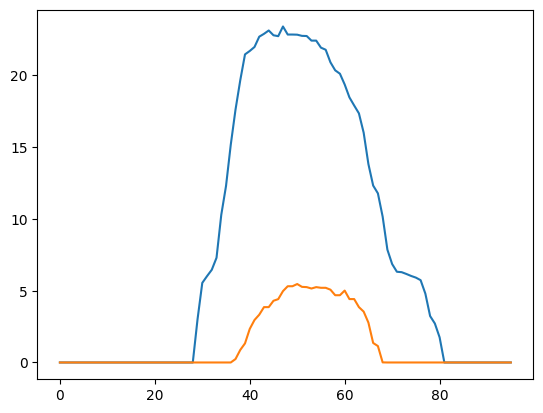

In [147]:
for i in range(K):
    plt.plot(median_vectors[i])

In [148]:
mean_vectors = []
for cluster_label in range(K):
    cluster_points = X[clusters == cluster_label]
    mean_vector = np.mean(cluster_points, axis=0)
    mean_vectors.append(mean_vector)

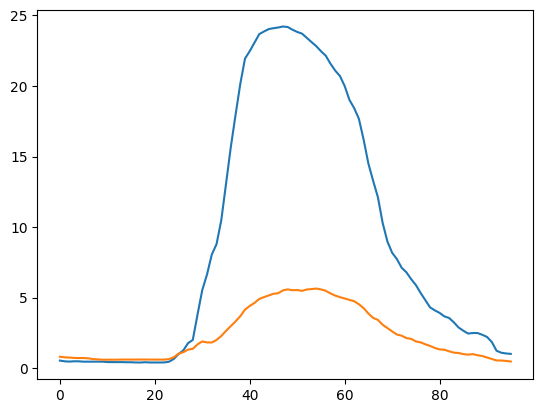

In [149]:
for i in range(K):
    plt.plot(mean_vectors[i])

In [150]:
max_vectors = []
for cluster_label in range(K):
    cluster_points = X[clusters == cluster_label]
    max_vector = np.max(cluster_points, axis=0)
    max_vectors.append(max_vector)

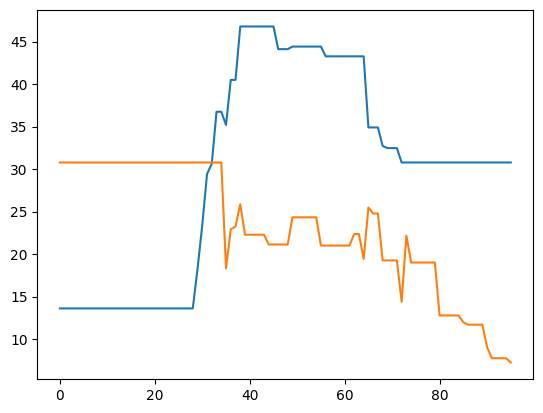

In [151]:
for i in range(K):
    plt.plot(max[i])

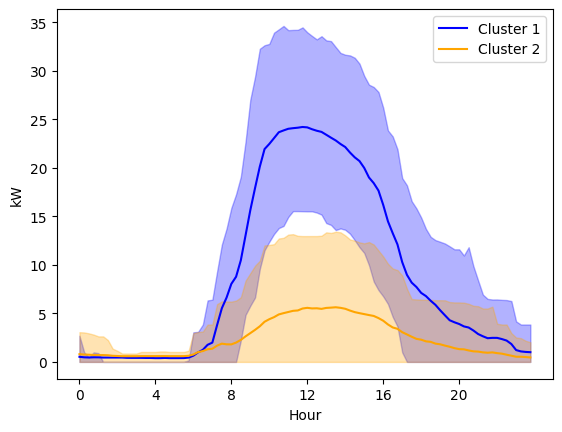

In [195]:


# for i in range(K):
#     plt.plot(median_[i])

# for i in range(K):
#     plt.plot(percentile10_vectors[i])

x = np.arange(0, 24, 0.25)

plt.fill_between(x, percentile90_vectors[0], percentile10_vectors[0], where=(percentile90_vectors[0] >= percentile90_vectors[0]), color='blue', alpha=0.3)
plt.plot(x, mean_vectors[0], color='blue', label='Cluster 1')

plt.fill_between(x, percentile90_vectors[1], percentile10_vectors[1], where=(percentile90_vectors[1] >= percentile90_vectors[1]), color='orange', alpha=0.3)
plt.plot(x, mean_vectors[1], color='orange', label='Cluster 2')

plt.xlabel("Hour")
plt.ylabel("kW")
plt.xticks(np.arange(0, 24, 4))
plt.legend()


In [163]:
# Calculate 90th percentile vector for each cluster
percentile90_vectors = []
for cluster_label in range(K):
    cluster_points = X[clusters == cluster_label]
    percentile90_vector = np.percentile(cluster_points, q=90, axis=0)
    percentile90_vectors.append(percentile90_vector)


percentile10_vectors = []
for cluster_label in range(K):
    cluster_points = X[clusters == cluster_label]
    percentile10_vector = np.percentile(cluster_points, q=10, axis=0)
    percentile10_vectors.append(percentile_vector)

TypeError: fill_between() missing 1 required positional argument: 'y1'

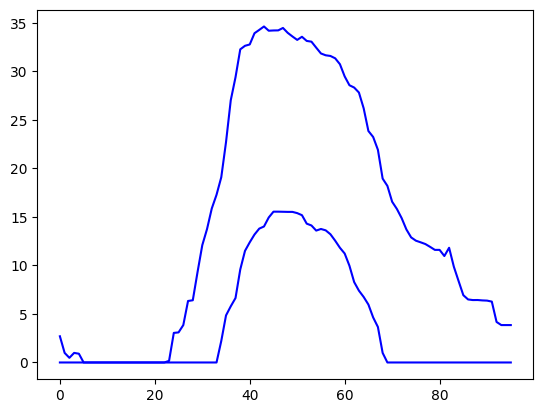

In [171]:
plt.plot(percentile90_vectors[0], color='blue')
plt.plot(percentile10_vectors[0], color='blue')
plt.fill_between([percentile10_vectors[0], percentile90_vectors[0]], alpha=0.2, color='blue')